# GLA AIML HW - WEEK 2

## Homework_DecisionTree_vs_RandomForest

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

np.random.seed(42)

def true_function(x):
    return np.sin(1.5 * np.pi * x)

N = 200
X = np.sort(np.random.rand(N))
y = true_function(X) + np.random.normal(0, 0.25, N)
X = X.reshape(-1, 1)

Xt, Xv, Yt, Yv = train_test_split(X, y, test_size=0.3, random_state=42)

### Part A — Decision Tree Regressor

#### 1. Train a single DecisionTreeRegressor with max_depth=None (fully grown).

In [2]:
dt_full = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_full.fit(Xt, Yt)

DecisionTreeRegressor(random_state=42)

#### 2. Compute Train MSE and Test MSE.

In [3]:
Yt_pred_full = dt_full.predict(Xt)
Yv_pred_full = dt_full.predict(Xv)

mset = mean_squared_error(Yt, Yt_pred_full)
msev = mean_squared_error(Yv, Yv_pred_full)

print(f"Train MSE (max_depth=None): {mset:.4f}")
print(f"Test MSE (max_depth=None): {msev:.4f}")

Train MSE (max_depth=None): 0.0000
Test MSE (max_depth=None): 0.1205


#### 3. Repeat for max_depth = 1, 2, 3, 5, 8, 12, None. Plot Train MSE and Test MSE vs max_depth on the same chart.

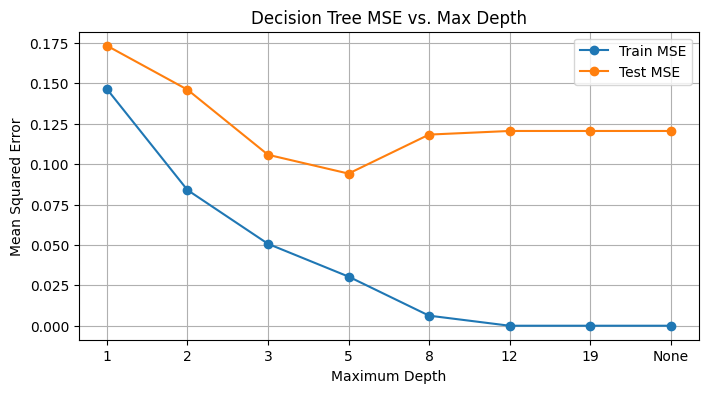

In [5]:
depths = [1, 2, 3, 5, 8, 12, 19 , None]
msetl = []
msevl = []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(Xt, Yt)

    Yt_pred = dt.predict(Xt)
    Yv_pred = dt.predict(Xv)

    msetl.append(mean_squared_error(Yt, Yt_pred))
    msevl.append(mean_squared_error(Yv, Yv_pred))

plt.figure(figsize=(8, 4))
plt.plot([str(d) for d in depths], msetl, label='Train MSE', marker='o')
plt.plot([str(d) for d in depths], msevl, label='Test MSE', marker='o')
plt.xlabel('Maximum Depth')
plt.ylabel('Mean Squared Error')
plt.title('Decision Tree MSE vs. Max Depth')
plt.legend()
plt.grid(True)
plt.show()

#### 4. In your own words: At max_depth=1, is the model biased or high-variance? Why?

At max_depth=1, the model is **biased**. It's too simple (underfits) to capture the data's patterns, leading to high errors on both training and test data.

#### 5. In your own words: At max_depth=None, what happens to Train MSE vs Test MSE? What does this indicate?

At max_depth=None, training MSE is very low, but test MSE is much higher. This shows the model has **high variance** and is **overfitting**, learning noise from the training data.

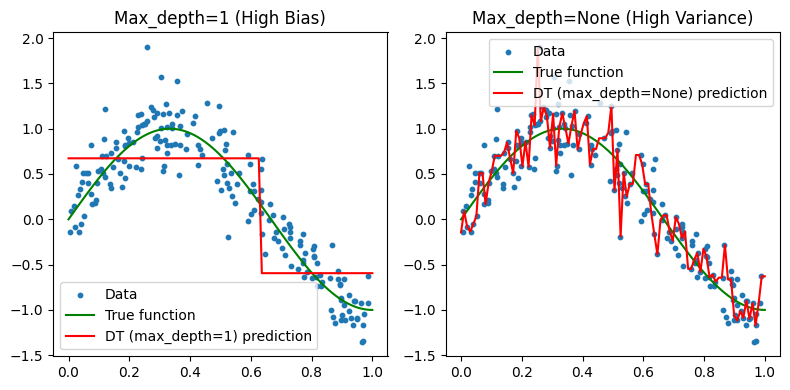

In [6]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
dt_biased = DecisionTreeRegressor(max_depth=1, random_state=42)
dt_biased.fit(Xt, Yt)
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
Y_true_plot = true_function(X_plot)
Y_pred_biased = dt_biased.predict(X_plot)
plt.scatter(X, y, s=10, label='Data')
plt.plot(X_plot, Y_true_plot, color='green', label='True function')
plt.plot(X_plot, Y_pred_biased, color='red', label='DT (max_depth=1) prediction')
plt.title('Max_depth=1 (High Bias)')
plt.legend()

plt.subplot(1, 2, 2)
dt_overfit = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_overfit.fit(Xt, Yt)
Y_pred_overfit = dt_overfit.predict(X_plot)
plt.scatter(X, y, s=10, label='Data')
plt.plot(X_plot, Y_true_plot, color='green', label='True function')
plt.plot(X_plot, Y_pred_overfit, color='red', label='DT (max_depth=None) prediction')
plt.title('Max_depth=None (High Variance)')
plt.legend()

plt.tight_layout()
plt.show()

### Part B — Random Forest Regressor

#### 6. Train a RandomForestRegressor with n_estimators=200, max_depth=None.

In [7]:
rfr = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
rfr.fit(Xt, Yt)

RandomForestRegressor(n_estimators=200, random_state=42)

#### 7. Compute Train MSE and Test MSE, and compare with the single fully-grown tree from Part A.

In [8]:
Yt_pred_rf = rfr.predict(Xt)
Yv_pred_rf = rfr.predict(Xv)

mset_rf = mean_squared_error(Yt, Yt_pred_rf)
msev_rf = mean_squared_error(Yv, Yv_pred_rf)

print(f"Random Forest Train MSE (n_estimators=200, max_depth=None): {mset_rf:.4f}")
print(f"Random Forest Test MSE (n_estimators=200, max_depth=None): {msev_rf:.4f}")
print(f"Single Decision Tree Test MSE (max_depth=None): {msev:.4f}")

Random Forest Train MSE (n_estimators=200, max_depth=None): 0.0105
Random Forest Test MSE (n_estimators=200, max_depth=None): 0.1012
Single Decision Tree Test MSE (max_depth=None): 0.1205


#### 8. Vary n_estimators = 1, 5, 10, 20, 50, 100, 200, 300 and plot Train/Test MSE vs n_estimators.

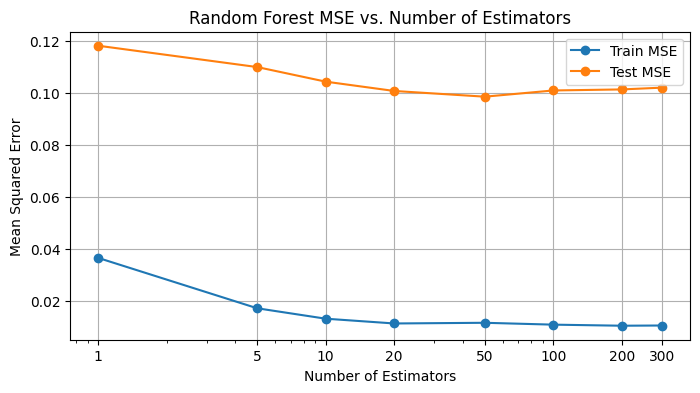

In [9]:
estimators = [1, 5, 10, 20, 50, 100, 200, 300]
msetl_rf = []
msevl_rf = []

for n in estimators:
    rfr_n = RandomForestRegressor(n_estimators=n, max_depth=None, random_state=42)
    rfr_n.fit(Xt, Yt)

    Yt_pred_n = rfr_n.predict(Xt)
    Yv_pred_n = rfr_n.predict(Xv)

    msetl_rf.append(mean_squared_error(Yt, Yt_pred_n))
    msevl_rf.append(mean_squared_error(Yv, Yv_pred_n))

plt.figure(figsize=(8, 4))
plt.plot(estimators, msetl_rf, label='Train MSE', marker='o')
plt.plot(estimators, msevl_rf, label='Test MSE', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Squared Error')
plt.title('Random Forest MSE vs. Number of Estimators')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.xticks(estimators, [str(e) for e in estimators])
plt.show()

#### 9. Why does Test MSE improve/plateau as n_estimators increases, while Train MSE stays roughly flat?

As more trees are added, the Random Forest's test error improves or levels off. This is because averaging many individual trees reduces the model's overall variance, making it more robust. Training error stays mostly flat as individual trees already fit the training data well.

#### 10. Does adding more trees ever cause the Random Forest to overfit more? Justify your answer using the concept of averaging.

No, more trees generally don't cause a Random Forest to overfit more. Each tree overfits its small data sample, but by averaging many such trees, their individual errors and noise cancel out. This reduces the overall model's variance, making it more stable and generalized, not more overfit.

### Part C — Comparative Study (Bias–Variance)

#### 11. Train 30 individual, fully-grown Decision Trees, each on a different bootstrap sample of the training data. Overlay all 30 predictions on one chart.

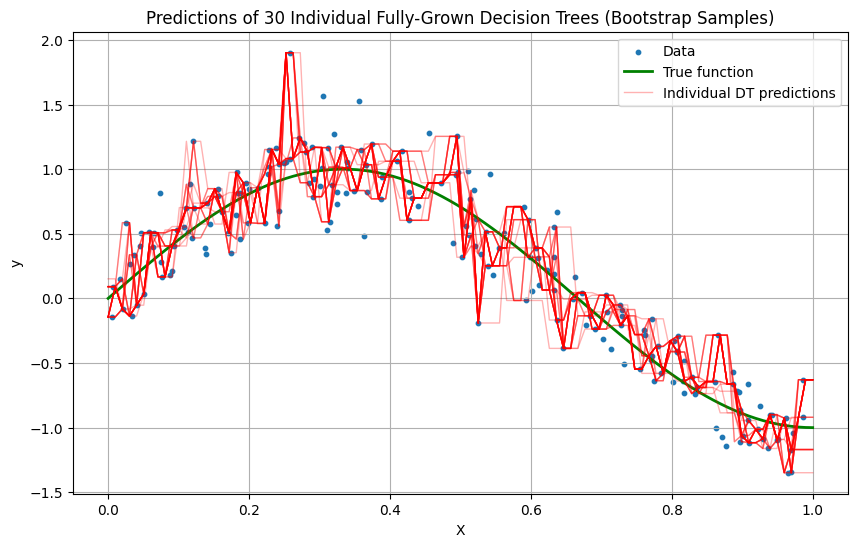

In [10]:
from sklearn.utils import resample

plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=10, label='Data')

X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
Y_true_plot = true_function(X_plot)
plt.plot(X_plot, Y_true_plot, color='green', linewidth=2, label='True function')

for i in range(30):
    Xt_sample, Yt_sample = resample(Xt, Yt, n_samples=len(Xt), random_state=i)
    dt_sample = DecisionTreeRegressor(max_depth=None, random_state=i)
    dt_sample.fit(Xt_sample, Yt_sample)
    Y_pred_sample = dt_sample.predict(X_plot)
    plt.plot(X_plot, Y_pred_sample, linestyle='-', alpha=0.3, color='red', linewidth=1)

plt.title('Predictions of 30 Individual Fully-Grown Decision Trees (Bootstrap Samples)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Data', 'True function', 'Individual DT predictions'])
plt.grid(True)
plt.show()

#### 12. On a separate chart, plot the prediction of a single Random Forest (200 trees) trained on the original training data.

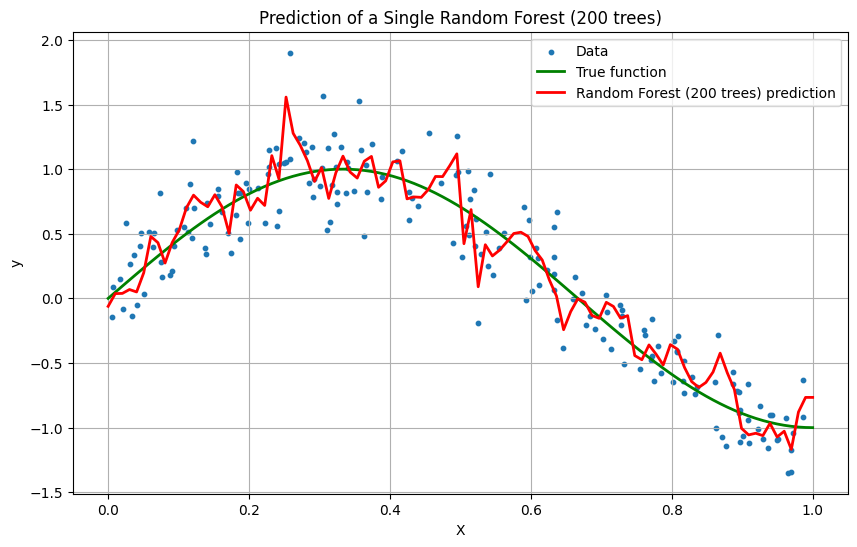

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=10, label='Data')

Y_pred_rf_plot = rfr.predict(X_plot)
plt.plot(X_plot, Y_true_plot, color='green', linewidth=2, label='True function')
plt.plot(X_plot, Y_pred_rf_plot, color='red', linewidth=2, label='Random Forest (200 trees) prediction')

plt.title('Prediction of a Single Random Forest (200 trees)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#### 13. Compare the two charts: which shows more spread/disagreement (variance)? Which is closer to the true function on average (bias)?

The chart with 30 individual trees shows much more spread (variance) and jagged predictions. The Random Forest chart is smoother, showing less variance and is, on average, closer to the true function (lower bias).

#### 14. Write one paragraph explaining why Random Forest reduces variance compared to a single Decision Tree, referencing bagging and averaging of largely uncorrelated errors.

Random Forest reduces variance because it uses **bagging** and **averaging**. It trains many decision trees on different data samples. Each tree might overfit, but their errors are mostly random and don't correlate. When their predictions are averaged, these random errors cancel each other out, making the final model more stable and reducing its overall variance.